## NLP Enrichment

In [ ]:
from keybert import KeyBERT
import sklearn
import json
from sentence_transformers import SentenceTransformer
model =  SentenceTransformer("Lajavaness/sentence-camembert-large")
kw_model = KeyBERT(model=model)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/809k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [3]:
# Expanded stopword list for Tunisian Legal Context
jort_stop_words = [
    # --- 1. Articles, Prépositions & Pronoms (Le bruit de fond absolu) ---
    'le', 'la', 'les', 'l', 'un', 'une', 'des', 'de', 'du', 'd',
    'au', 'aux', 'à', 'a', 'en', 'dans', 'sur', 'sous', 'pour', 'par',
    'avec', 'sans', 'vers', 'envers', 'contre', 'entre', 'parmi', 'outre',
    'qui', 'que', 'quoi', 'dont', 'où', 'qu', 'y', 'ne', 'n',
    'lequel', 'laquelle', 'lesquels', 'lesquelles', 'auquel', 'auxquels', 'auxquelles',
    'duquel', 'desquels', 'desquelles',

    # --- 2. Démonstratifs & Possessifs ---
    'ce', 'cet', 'cette', 'ces', 'c', 'celui', 'celle', 'ceux', 'celles', 'ceci', 'cela',
    'mon', 'ton', 'son', 'ma', 'ta', 'sa', 'mes', 'tes', 'ses',
    'notre', 'votre', 'leur', 'nos', 'vos', 'leurs', 's',

    # --- 3. Conjonctions & Liens Logiques ---
    'mais', 'ou', 'et', 'donc', 'or', 'ni', 'car',
    'si', 'sinon', 'lorsque', 'puisque', 'quoique',
    'ainsi', 'aussi', 'alors', 'puis', 'ensuite', 'néanmoins', 'toutefois', 'cependant',

    # --- 4. Adverbes, Quantificateurs & Modificateurs ---
    'tout', 'toute', 'tous', 'toutes', 'chaque', 'aucun', 'aucune',
    'plusieurs', 'divers', 'diverses', 'tel', 'telle', 'tels', 'telles',
    'quel', 'quelle', 'quels', 'quelles', 'même', 'mêmes', 'autre', 'autres',
    'plus', 'moins', 'très', 'trop', 'peu', 'beaucoup', 'bien', 'mal',
    'également', 'notamment', 'seulement', 'uniquement', 'généralement',

    # --- 5. Verbes Communs (Être, Avoir, Devoir, Pouvoir, Faire) ---
    'est', 'sont', 'sera', 'seront', 'était', 'étaient', 'été', 'soit', 'soient',
    'ont', 'aura', 'auront', 'avait', 'avaient', 'eu',
    'doit', 'doivent', 'devra', 'devront', 'devant',
    'peut', 'peuvent', 'pourra', 'pourront', 'pouvant',
    'faire', 'fait', 'font', 'fera', 'feront', 'faisant', 'agit', 'agissant',

    # --- 6. Bruit Administratif et Structurel Juridique (JORT / Codes) ---
    'article', 'articles', 'alinéa', 'alinéas', 'paragraphe', 'paragraphes',
    'chapitre', 'chapitres', 'titre', 'titres', 'section', 'sections',
    'loi', 'lois', 'décret', 'décrets', 'arrêté', 'arrêtés', 'code', 'circulaire',
    'texte', 'textes', 'n°', 'numéro', 'numéros',
    'présent', 'présente', 'présents', 'présentes',
    'suivant', 'suivante', 'suivants', 'suivantes',
    'susvisé', 'susvisée', 'susvisés', 'susvisées',
    'susmentionné', 'susmentionnée', 'susmentionnés', 'susmentionnées',

    # --- 7. Vocabulaire de Référence Juridique (Souvent inutile en tant que mot-clé) ---
    'relatif', 'relative', 'relatifs', 'relatives',
    'portant', 'fixant', 'abrogeant', 'modifiant', 'complétant', 'approuvant',
    'disposition', 'dispositions', 'prévu', 'prévue', 'prévus', 'prévues',
    'visé', 'visée', 'visés', 'visées', 'mentionné', 'mentionnée', 'mentionnés',
    'conformément', 'vertu', 'application', 'vigueur', 'objet', 'effet',
    'cas', 'réserve', 'condition', 'nonobstant', 'égard',

    # --- 8. Temps, Délais & Chiffres ---
    'jour', 'jours', 'mois', 'an', 'ans', 'année', 'années', 'date',
    'délai', 'délais', 'compter', 'lors', 'avant', 'après', 'depuis', 'pendant', 'fin',
    'révolus', 'un', 'deux', 'trois', 'quatre', 'cinq', 'dix', 'cent', 'mille'
]

In [5]:
import re

test_articles = [
    "Les obligations dérivent des conventions et autres déclarations de volonté, des quasi contrats, des délits et des quasi-délits.",
    "Les éléments nécessaires pour la validité des obligations qui dérivent d'une déclaration de volonté sont : la capacité de s'obliger ; une déclaration valable de volonté portant sur les éléments essentiels de l'obligation, un objet certain pouvant former objet d'obligation, une cause licite de s'obliger.",
    "Toute personne est capable d'obliger et de s'obliger sauf si elle est déclarée incapable par la loi.",
    "La différence du culte ne crée aucune différence entre les musulmans et les non-musulmans, en ce qui concerne la capacité de contracter et les effets des obligations valablement formées par ces derniers et envers eux.",
    "Sont absolument incapables de contracter, si ce n'est par les personnes qui les représentent : 1) les mineurs jusqu'à l'âge de treize ans révolus ; 2) les majeurs atteints d'aliénation mentale qui les prive complément de leurs facultés ; 3) les personnes morales que la loi assimile aux mineurs .",
    "Ont une capacité limitée : 1) les mineurs au-dessus de treize ans et jusqu'à dix-huit ans révolus, assistés par leur père ou tuteur ; 2) les interdits pour faiblesse d'esprit ou prodigalité, non assistés par leur conseil judiciaire, dans les cas ou la loi requiert cette assistance ; 3) les interdits pour insolvabilité déclarée. Et généralement tous ceux auxquels la loi défend certains contrats.",

    "Le contrat est un accord de volontés entre deux ou plusieurs personnes destiné à créer, modifier, transmettre ou éteindre des obligations. Il peut être conclu par écrit ou verbalement, sauf dans les cas où la loi exige une forme particulière. Les parties au contrat doivent avoir la capacité juridique de contracter et le consentement doit être libre et éclairé. Le contrat doit également avoir un objet licite et une cause licite pour être valide."


]
test_articles = [str(article) for article in test_articles]

raw_batch_results = kw_model.extract_keywords(
    test_articles,
    keyphrase_ngram_range=(1, 4),
    top_n=5,
    use_mmr=True,
    diversity = 0.3,
    stop_words=jort_stop_words
)

LINE = "—" * 90
print(f"\n{LINE}")
print(f"🔍 ANALYSE BATCH : {len(test_articles)} ARTICLES DU CODE CIVIL")
print(f"{LINE}\n")
# 2. Boucle de post-traitement et d'affichage
for i, keywords in enumerate(raw_batch_results):
    print(f"📄 ARTICLE {i+1} : {test_articles[i][:80]}...")

    final_selection = []
    seen = set()

    # Logique de nettoyage par article
    for concept, score in keywords:
        # Nettoyage Regex (Particules de début)
        clean = re.sub(r'^(et|de|le|la|les|un|une|d|l|s|au|aux|en|ou|si)\s+', '', concept, flags=re.IGNORECASE).strip()

        # Filtres : Score min 0.22, longueur min 4, pas de doublons
        if score > 0.22 and len(clean) > 3 and clean.lower() not in seen:
            final_selection.append((clean.capitalize(), score))
            seen.add(clean.lower())

    # Affichage des résultats filtrés (Top 3 par article)
    if not final_selection:
        print("   ⚠️ Aucun concept validé.")
    else:
        for concept, score in final_selection[:3]:
            # Barre visuelle de confiance
            bar_width = int(score * 20)
            bar = "█" * bar_width
            print(f"   {bar.ljust(20)} | {score:.4f} | {concept}")

    print(f"{'·' * 90}") # Séparateur discret entre articles

print(f"\n✅ Analyse terminée.")




——————————————————————————————————————————————————————————————————————————————————————————
🔍 ANALYSE BATCH : 7 ARTICLES DU CODE CIVIL
——————————————————————————————————————————————————————————————————————————————————————————

📄 ARTICLE 1 : Les obligations dérivent des conventions et autres déclarations de volonté, des ...
   ████████████████     | 0.8057 | Obligations dérivent conventions
   ███████████████      | 0.7873 | Obligations dérivent conventions déclarations
   ████████████         | 0.6247 | Quasi contrats délits quasi
··························································································
📄 ARTICLE 2 : Les éléments nécessaires pour la validité des obligations qui dérivent d'une déc...
   ██████████████       | 0.7118 | Validité obligations dérivent déclaration
   ██████████████       | 0.7032 | Obligations dérivent déclaration volonté
   █████████████        | 0.6972 | Déclaration volonté capacité obliger
·················································

### MAIN Script

In [7]:
import json
import re
import gc
import time

# ==========================================
# CONFIGURATION
# ==========================================
input_filename = "scraped_legal_data.jsonl"
output_filename = "scraped_enriched_data.jsonl"
BATCH_SIZE = 50  # Nombre d'articles par appel à KeyBERT

# ⚠️ ASSUREZ-VOUS QUE CES VARIABLES EXISTENT DÉJÀ DANS VOTRE SCRIPT :
# kw_model = KeyBERT(...)
# jort_stop_words = [...]

def process_and_write_batch(batch_data, outfile, batch_num):
    """Extrait les mots-clés d'un lot, les filtre, et écrit les résultats."""

    # 1. Extraire uniquement les textes pour le modèle
    texts = [" ".join(str(data.get("text", "")).split()[:350]) for data in batch_data]

    # 2. Appel groupé (Batch) au modèle KeyBERT
    # top_n=5 pour avoir du choix si les premiers sont rejetés par vos filtres
    raw_batch_results = kw_model.extract_keywords(
        texts,
        keyphrase_ngram_range=(1, 4),
        top_n=5,
        use_mmr=True,
        diversity = 0.3,
        stop_words=jort_stop_words
    )

    # --- AFFICHAGE EN-TÊTE DE LOT ---
    LINE = "—" * 90
    print(f"\n{LINE}")
    print(f"📦 BATCH {batch_num} COMPLÉTÉ ({len(batch_data)} articles traités)")
    print(f"{LINE}")

    # 3. Post-traitement et affectation aux données JSON
    for i, (data, keywords) in enumerate(zip(batch_data, raw_batch_results)):
        final_selection = []
        seen = set()

        for concept, score in keywords:
            # Nettoyage Regex : [\s\']+ permet de gérer "de la " mais aussi "d'obligation"
            clean = re.sub(r'^(?:et|de|le|la|les|un|une|d|l|s|au|aux|en|ou|si)[\s\']+', '', concept, flags=re.IGNORECASE).strip()

            # Filtres : Score min 0.22, longueur min 4, pas de doublons
            if score > 0.22 and len(clean) > 3 and clean.lower() not in seen:
                final_selection.append((clean.capitalize(), score))
                seen.add(clean.lower())

        # Affectation dans les métadonnées (on prend uniquement le meilleur valide)
        if "metadata" not in data:
            data["metadata"] = {}

        if final_selection:
            best_concept, best_score = final_selection[0]
            data["metadata"]["keyword"] = best_concept
            data["metadata"]["keyword_score"] = round(best_score, 4)
        else:
            data["metadata"]["keyword"] = None
            data["metadata"]["keyword_score"] = 0

        # --- APERÇU DES 2 PREMIERS ARTICLES DU LOT ---
        if i < 2:
            article_text = texts[i].replace("\n", " ")
            print(f"📄 APERÇU {i+1} : {article_text[:80]}...")

            if final_selection:
                bar_width = int(best_score * 20)
                bar = "█" * bar_width
                print(f"   {bar.ljust(20)} | {best_score:.4f} | {best_concept}")
            else:
                print("   ⚠️ Aucun concept validé (score < 0.22 ou filtré par Regex).")
            print(f"{'·' * 90}")

        # 4. Écriture du JSONL final
        outfile.write(json.dumps(data, ensure_ascii=False) + "\n")


# ==========================================
# EXÉCUTION PRINCIPALE
# ==========================================
print("📊 Analyse du fichier source...")
try:
    with open(input_filename, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for _ in f)
except FileNotFoundError:
    print(f"❌ Erreur : Le fichier {input_filename} est introuvable.")
    total_lines = 0

if total_lines > 0:
    print(f"📄 Total à traiter : {total_lines} articles (Taille des lots : {BATCH_SIZE}).")

    start_time = time.time()
    processed_count = 0
    batch_num = 1
    current_batch = []

    with open(input_filename, "r", encoding="utf-8") as infile, \
         open(output_filename, "w", encoding="utf-8") as outfile:

        for line in infile:
            if not line.strip(): continue

            current_batch.append(json.loads(line))

            # Quand le lot est plein
            if len(current_batch) >= BATCH_SIZE:
                process_and_write_batch(current_batch, outfile, batch_num)

                # Mise à jour de la progression
                processed_count += len(current_batch)
                percent = (processed_count / total_lines) * 100
                bar = "█" * int(percent / 2) + "-" * (50 - int(percent / 2))
                elapsed = time.time() - start_time
                print(f"⏳ Progression Globale : |{bar}| {percent:.1f}% ({processed_count}/{total_lines}) - {elapsed:.0f}s")

                # Préparation du lot suivant
                current_batch.clear()
                batch_num += 1
                gc.collect() # Nettoyage mémoire

        # Traitement du dernier lot (s'il reste des articles)
        if current_batch:
            process_and_write_batch(current_batch, outfile, batch_num)
            processed_count += len(current_batch)
            percent = (processed_count / total_lines) * 100
            bar = "█" * int(percent / 2) + "-" * (50 - int(percent / 2))
            elapsed = time.time() - start_time
            print(f"⏳ Progression Globale : |{bar}| {percent:.1f}% ({processed_count}/{total_lines}) - {elapsed:.0f}s")
            current_batch.clear()
            gc.collect()

    print(f"\n✅ Enrichissement terminé avec succès en {time.time() - start_time:.1f} secondes.")
    print(f"💾 Résultat final sauvegardé dans : {output_filename}")

📊 Analyse du fichier source...
📄 Total à traiter : 1116 articles (Taille des lots : 50).

——————————————————————————————————————————————————————————————————————————————————————————
📦 BATCH 1 COMPLÉTÉ (50 articles traités)
——————————————————————————————————————————————————————————————————————————————————————————
📄 APERÇU 1 : Les obligations dérivent des conventions et autres déclarations de volonté, des ...
   ████████████████     | 0.8057 | Obligations dérivent conventions
··························································································
📄 APERÇU 2 : Les éléments nécessaires pour la validité des obligations qui dérivent d'une déc...
   ██████████████       | 0.7118 | Validité obligations dérivent déclaration
··························································································
⏳ Progression Globale : |██------------------------------------------------| 4.5% (50/1116) - 5s

————————————————————————————————————————————————————————————————————

Model	Pearson correlation	Spearman correlation
dangvantuan/sentence-camembert-large	85.9	85.8
dangvantuan/sentence-camembert-base	82.36	81.64
distiluse-base-multilingual-cased	78.62	77.48
GPT-3 (text-davinci-003)	82	NaN
GPT-(text-embedding-ada-002)	79.05	77.56

## Embedding (Cohere)

In [1]:
import os
import json
import time
import uuid
import cohere
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PointStruct
from dotenv import load_dotenv

# Force reload of .env
load_dotenv(override=True)

# Initialize Clients
co = cohere.Client(os.getenv("COHERE_API_KEY"))

qdrant = QdrantClient(
    url=os.getenv("QDRANT_URL"), 
    api_key=os.getenv("QDRANT_API_KEY")
)

# Test connection
print(f"📡 Cohere Key: {os.getenv('COHERE_API_KEY')[:5]}...")
print(f"☁️ Qdrant URL: {os.getenv('QDRANT_URL')}")

📡 Cohere Key: r56Wv...
☁️ Qdrant URL: https://d8ffeafe-671c-4ead-9cdb-d85705b4204f.eu-central-1-0.aws.cloud.qdrant.io


In [42]:
JSONL_FILE = "scraped_enriched_data_truncated.jsonl" # Update if your path is different
chunks = []

with open(JSONL_FILE, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            chunks.append(json.loads(line))

print(f"📖 Loaded {len(chunks)} sections.")
print("🔍 First Chunk Example:")
print(json.dumps(chunks[0], indent=2, ensure_ascii=False))

📖 Loaded 1116 sections.
🔍 First Chunk Example:
{
  "id": "code-obligations-contrats_1",
  "article_number": "1",
  "text": "Les obligations dérivent des conventions et autres déclarations de volonté, des quasi contrats, des délits et des quasi-délits.",
  "metadata": {
    "source": "Code Obligations Contrats",
    "keyword": "Obligations dérivent conventions",
    "keyword_score": 0.8057
  }
}


In [ ]:
# --- STEP 1: PREPARE ALL TEXTS ---
print(f"📝 Preparing {len(chunks)} texts for embedding...")
full_text_list = [
    f"{c.get('metadata', {}).get('keyword', 'source')} : {c['text']}" 
    for c in chunks
]


In [ ]:

# --- STEP 2: BATCH EMBED (Collect all vectors in RAM) ---
# We must loop here because Cohere has a 96-item limit per API call
all_vectors = []
BATCH_SIZE = 50

print(f"🔢 Generating all embeddings (Total calls needed: {len(chunks)//BATCH_SIZE + 1})...")

for i in range(0, len(full_text_list), BATCH_SIZE):
    batch = full_text_list[i : i + BATCH_SIZE]
    
    response = co.embed(
        texts=batch,
        model="embed-multilingual-v3.0",
        input_type="search_document"
    )
    all_vectors.extend(response.embeddings)
    
    # Respect trial rate limits
    time.sleep(0.5)

print(f"✅ Collected {len(all_vectors)} vectors in memory.")

📝 Preparing 1116 texts for embedding...
🔢 Generating all embeddings (Total calls needed: 12)...
✅ Collected 1116 vectors in memory.


In [44]:
print (all_vectors[0][:5]) # Aperçu du début du premier vecteur

[-0.024383545, -0.013648987, -0.025619507, 0.020645142, 0.0051994324]


## Vector DB (qdrant)

In [41]:
COLLECTION_NAME = "tunisian_laws"

if not qdrant.collection_exists(COLLECTION_NAME):
    qdrant.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
    )
    print(f"✅ Collection '{COLLECTION_NAME}' created.")
else:
    print(f"ℹ️ Collection '{COLLECTION_NAME}' already exists.")

✅ Collection 'tunisian_laws' created.


In [49]:
# --- STEP 3: ASSEMBLE ALL POINTS ---
# Use zip to marry your chunks with your vectors in one line
print("🏗️ Assembling Qdrant Point structures...")
all_points = [
    PointStruct(
        id=str(uuid.uuid5(uuid.NAMESPACE_DNS, chunk['text'] + chunk['id'])),
        vector=vector,
        payload={
            "text": chunk["text"],
            "article_number": chunk.get("article_number", "N/A"),
            "keyword": chunk.get("metadata", {}).get("keyword", ""),
            "keyword_score": chunk.get("metadata", {}).get("keyword_score", None),
            "source": chunk.get("metadata", {}).get("source", "Inconnu")
        }
    )
    for chunk, vector in zip(chunks, all_vectors)
]
print (f"✅ Assembled {len(all_points)} points ready for upload.")
print (f"Sample point: {all_points[0].id}")
print (f"Sample point: {all_points[0].vector[:5]}") # Aperçu du début du vecteur du premier point
print (f"Sample point: {all_points[0].payload}")

🏗️ Assembling Qdrant Point structures...
✅ Assembled 1116 points ready for upload.
Sample point: 5fb22818-e2c8-5da7-a53c-e2cea4f53204
Sample point: [-0.024383545, -0.013648987, -0.025619507, 0.020645142, 0.0051994324]
Sample point: {'text': 'Les obligations dérivent des conventions et autres déclarations de volonté, des quasi contrats, des délits et des quasi-délits.', 'article_number': '1', 'keyword': 'Obligations dérivent conventions', 'keyword_score': 0.8057, 'source': 'Code Obligations Contrats'}


In [50]:
# --- STEP 4: BATCHED UPLOAD (Prevents Timeouts) ---
UPLOAD_BATCH_SIZE = 50  # Upload 50 points at a time
print(f"🚀 Uploading {len(all_points)} points to Qdrant Cloud in batches of {UPLOAD_BATCH_SIZE}...")

for i in range(0, len(all_points), UPLOAD_BATCH_SIZE):
    batch = all_points[i : i + UPLOAD_BATCH_SIZE]
    
    try:
        qdrant.upsert(
            collection_name=COLLECTION_NAME,
            points=batch,
            wait=True # Ensures the batch is processed before moving to the next
        )
        print(f"✅ Uploaded points {i} to {i + len(batch)}")
    except Exception as e:
        print(f"❌ Error uploading batch {i}: {e}")
        # Wait a bit and try one more time if it fails
        time.sleep(5)
        qdrant.upsert(collection_name=COLLECTION_NAME, points=batch)

print("🎯 SUCCESS! Your entire library is indexed and saved in the cloud.")

🚀 Uploading 1116 points to Qdrant Cloud in batches of 50...
✅ Uploaded points 0 to 50
✅ Uploaded points 50 to 100
✅ Uploaded points 100 to 150
✅ Uploaded points 150 to 200
✅ Uploaded points 200 to 250
✅ Uploaded points 250 to 300
✅ Uploaded points 300 to 350
✅ Uploaded points 350 to 400
✅ Uploaded points 400 to 450
✅ Uploaded points 450 to 500
✅ Uploaded points 500 to 550
✅ Uploaded points 550 to 600
✅ Uploaded points 600 to 650
✅ Uploaded points 650 to 700
✅ Uploaded points 700 to 750
✅ Uploaded points 750 to 800
✅ Uploaded points 800 to 850
✅ Uploaded points 850 to 900
✅ Uploaded points 900 to 950
✅ Uploaded points 950 to 1000
✅ Uploaded points 1000 to 1050
✅ Uploaded points 1050 to 1100
✅ Uploaded points 1100 to 1116
🎯 SUCCESS! Your entire library is indexed and saved in the cloud.


## Retrieval

### 1. no reranking

In [14]:
def juridical_search(query, limit=5):
    # 1. Get Vector from Cohere
    v = co.embed(
        texts=[query], 
        model="embed-multilingual-v3.0", 
        input_type="search_query"
    ).embeddings[0]
    
    # 2. Search directly in Qdrant
    response = qdrant.query_points(
        collection_name="tunisian_laws", 
        query=v, 
        limit=limit
    )
    search_results = response.points
    
    if search_results:
        print(f"📡 Qdrant Top ID: {search_results[0].payload.get('article_number')} (Score: {search_results[0].score:.4f})")

    # 3. Format the results (No Reranking)
    final_results = []
    
    for point in search_results:
        final_results.append({
            "id": point.payload.get('article_number'),
            "text": point.payload.get('text'),
            "context": point.payload.get('keyword'),
            "source": point.payload.get('source'), 
            # Passing Qdrant's score into 'rerank_score' so your testing script doesn't break
            "rerank_score": point.score 
        })
    
    return final_results

In [15]:
import math
import time 
import importlib
import test_retriever_dataset
importlib.reload(test_retriever_dataset)
from test_retriever_dataset import mock_test_dataset 

# ==========================================
# 1. METRIC CALCULATION FUNCTIONS
# ==========================================

def get_precision_at_k(retrieved_ids, relevant_ids, k):
    """Precision@K: Out of the top K retrieved, how many are relevant?"""
    retrieved_k = retrieved_ids[:k]
    if not retrieved_k:
        return 0.0
    relevant_retrieved = set(retrieved_k).intersection(set(relevant_ids))
    return len(relevant_retrieved) / k

def get_recall_at_k(retrieved_ids, relevant_ids, k):
    """Recall@K: Out of all relevant docs, how many did we find in top K?"""
    retrieved_k = retrieved_ids[:k]
    if not relevant_ids:
        return 0.0
    relevant_retrieved = set(retrieved_k).intersection(set(relevant_ids))
    return len(relevant_retrieved) / len(relevant_ids)

def get_mrr(retrieved_ids, relevant_ids):
    """Mean Reciprocal Rank: 1 / (rank of the FIRST relevant document)"""
    for i, doc_id in enumerate(retrieved_ids):
        if doc_id in relevant_ids:
            return 1.0 / (i + 1)
    return 0.0

def get_ndcg_at_k(retrieved_ids, relevant_ids, k):
    """NDCG@K: Measures ranking quality (relevant docs higher up = better score)"""
    retrieved_k = retrieved_ids[:k]
    
    # Calculate DCG
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_k):
        if doc_id in relevant_ids:
            # Binary relevance: 1 if relevant, 0 if not
            dcg += 1.0 / math.log2(i + 2) # i+2 because index is 0-based
            
    # Calculate IDCG (Ideal DCG)
    idcg = 0.0
    # The ideal ranking puts all relevant docs at the very top
    ideal_retrieved = min(len(relevant_ids), k)
    for i in range(ideal_retrieved):
        idcg += 1.0 / math.log2(i + 2)
        
    if idcg == 0.0:
        return 0.0
    return dcg / idcg



def evaluate_retriever(test_dataset, k=5):
    """
    Evaluates the juridical_search function against a test dataset,
    respecting Cohere's Free Tier Rate Limits (10 calls/min).
    """
    total_precision = 0.0
    total_recall = 0.0
    total_mrr = 0.0
    total_ndcg = 0.0
    num_queries = len(test_dataset)

    print(f"🚀 Starting evaluation over {num_queries} queries...\n")

    for index, item in enumerate(test_dataset):
        query = item['query']
        ground_truth_ids = item['relevant_ids']
        
        ground_truth_ids = [article_id.split("_")[1] for article_id in ground_truth_ids ]
        
        print(f"[{index + 1}/{num_queries}] Query: '{query}'")
        
        # --- Retry Logic for Rate Limits ---
        success = False
        results = []
        retrieved_ids = []
        
        while not success:
            try:
                # 1. Call search function
                results = juridical_search(query)
                
                # Extract IDs for metric calculations
                retrieved_ids = [res['id'] for res in results]
                success = True
                
            except Exception as e:
                error_msg = str(e)
                if '429' in error_msg or 'Trial key' in error_msg:
                    print("  ⏳ Cohere Rate limit hit (10 calls/min). Pausing for 60 seconds...")
                    time.sleep(60)
                else:
                    print(f"  ❌ Error: {e}")
                    break
        
        if not success:
            continue

        # 2. Calculate metrics
        p_at_k = get_precision_at_k(retrieved_ids, ground_truth_ids, k)
        r_at_k = get_recall_at_k(retrieved_ids, ground_truth_ids, k)
        mrr = get_mrr(retrieved_ids, ground_truth_ids)
        ndcg = get_ndcg_at_k(retrieved_ids, ground_truth_ids, k)

        # Add to totals
        total_precision += p_at_k
        total_recall += r_at_k
        total_mrr += mrr
        total_ndcg += ndcg

        # 3. PRINT RESULTS WITH SOURCE
        print(f"  🎯 Ground Truth Expected: {ground_truth_ids}")
        print("  📄 Top Retrieved Articles:")
        
        for rank, res in enumerate(results, 1):
            article_id = res.get('id', 'N/A')
            source = res.get('source', 'Unknown Source') # Extracts the source
            score = res.get('rerank_score', 0.0)
            
            # Check if this article was a "Hit" (in the ground truth)
            is_hit = "✅" if article_id in ground_truth_ids else "❌"
            
            # Print nicely formatted
            print(f"     {rank}. {is_hit} {article_id} | Source: {source} | Score: {score:.4f}")
            
        print(f"  📊 Metrics -> P@{k}: {p_at_k:.2f} | R@{k}: {r_at_k:.2f} | MRR: {mrr:.2f} | NDCG@{k}: {ndcg:.2f}\n")

        # 4. Wait to respect rate limits
        if index < num_queries - 1:
            print("  ⏱️ Waiting 13 seconds to respect Cohere API limits...\n")
            time.sleep(13)

    # Calculate Averages
    avg_precision = total_precision / num_queries
    avg_recall = total_recall / num_queries
    avg_mrr = total_mrr / num_queries
    avg_ndcg = total_ndcg / num_queries

    print("========================================")
    print("📈 OVERALL EVALUATION RESULTS")
    print("========================================")
    print(f"Average Precision@{k}: {avg_precision:.4f}")
    print(f"Average Recall@{k}:    {avg_recall:.4f}")
    print(f"Mean Reciprocal Rank:  {avg_mrr:.4f}")
    print(f"Average NDCG@{k}:      {avg_ndcg:.4f}")
    print("========================================")

    return {
        "precision": avg_precision,
        "recall": avg_recall,
        "mrr": avg_mrr,
        "ndcg": avg_ndcg
    }
eval_results = evaluate_retriever(mock_test_dataset, k=5)

🚀 Starting evaluation over 51 queries...

[1/51] Query: 'Qui est considéré juridiquement capable de contracter ?'
📡 Qdrant Top ID: 5 (Score: 0.6956)
  🎯 Ground Truth Expected: ['3']
  📄 Top Retrieved Articles:
     1. ❌ 5 | Source: Code Obligations Contrats | Score: 0.6956
     2. ❌ 14 | Source: Code Obligations Contrats | Score: 0.6502
     3. ✅ 3 | Source: Code Obligations Contrats | Score: 0.6498
     4. ❌ 8 | Source: Code Obligations Contrats | Score: 0.6486
     5. ❌ 549 | Source: Code Obligations Contrats | Score: 0.6003
  📊 Metrics -> P@5: 0.20 | R@5: 1.00 | MRR: 0.33 | NDCG@5: 0.50

  ⏱️ Waiting 13 seconds to respect Cohere API limits...

[2/51] Query: 'Quels sont les cas d'incapacité absolue en droit des contrats ?'
📡 Qdrant Top ID: 14 (Score: 0.6648)
  🎯 Ground Truth Expected: ['5']
  📄 Top Retrieved Articles:
     1. ❌ 14 | Source: Code Obligations Contrats | Score: 0.6648
     2. ❌ 35 | Source: Code Obligations Contrats | Score: 0.6535
     3. ❌ 65 | Source: Code Obligation

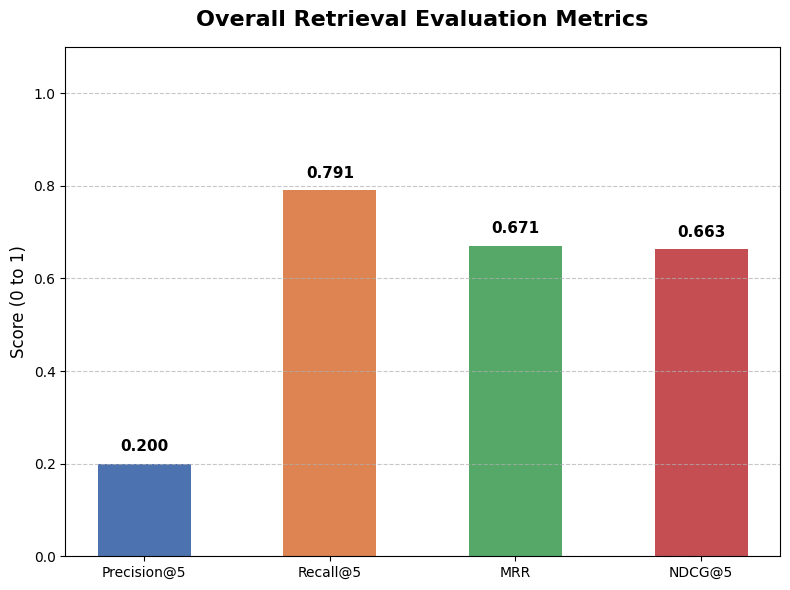

In [16]:
import matplotlib.pyplot as plt

# Extract values directly from your 'results' dictionary
labels = ['Precision@5', 'Recall@5', 'MRR', 'NDCG@5']
values = [
    eval_results.get('precision', 0),
    eval_results.get('recall', 0),
    eval_results.get('mrr', 0),
    eval_results.get('ndcg', 0)
]
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors, width=0.5)

# Formatting
plt.ylim(0, 1.1)
plt.title('Overall Retrieval Evaluation Metrics', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
             f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
def juridical_search(query, limit=10):
    # 1. Get Vector from Cohere
    v = co.embed(
        texts=[query], 
        model="embed-multilingual-v3.0", 
        input_type="search_query"
    ).embeddings[0]
    
    # 2. Initial Search in Qdrant
    response = qdrant.query_points(
        collection_name="tunisian_laws", 
        query=v, 
        limit=limit
    )
    search_results = response.points # This is the "Before" list
    
    print(f"📡 Qdrant found {len(search_results)} candidates.")
    print(f"Original Top ID: {search_results[0].payload.get('article_number')}")

    # 3. Prepare texts for Reranker
    docs = [res.payload['text'] for res in search_results]
    
    # 4. Execute Rerank
    rerank_response = co.rerank(
        query=query,
        documents=docs,
        top_n=5,
        model="rerank-multilingual-v3.0"
    )
    
    # 5. THE CRITICAL STEP: RE-ORDER THE LIST
    # We create a brand new list in the order Cohere decided
    final_ranked_results = []
    
    for hit in rerank_response.results:
        # Look up the original point using the index provided by Cohere
        original_point = search_results[hit.index]
        
        # Build a new dictionary with the data + the new score
        final_ranked_results.append({
            "id": original_point.payload.get('article_number'),
            "text": original_point.payload.get('text'),
            "context": original_point.payload.get('keyword'),
            "source": original_point.payload.get('source'), # 👈 ADD THIS LINE
            "rerank_score": hit.relevance_score
        })

    print(f"🏆 Reranked Top ID: {final_ranked_results[0]['id']} (Score: {final_ranked_results[0]['rerank_score']:.4f})")
    
    return final_ranked_results



In [3]:
# TEST IT:
results = juridical_search("comment prouver la force majeure en droit tunisien?") # Use your actual question
print(results)

📡 Qdrant found 10 candidates.
Original Top ID: 240
🏆 Reranked Top ID: 450 (Score: 0.0155)
[{'id': '450', 'text': "Les actes sous seing privé font foi de leur date, entre les parties, leurs héritiers et leurs ayant cause à titre particulier, agissant au nom de leur débiteur. Ils n’ont de date contre les tiers que: 1) du jour où ils ont été enregistrés, soit en Tunisie, soit à l’étranger ; 2) du jour ou l’acte a été déposé dans les mains d’un officier public ; 3) si l’acte est souscrit, soit comme partie, soit comme témoin, par une personne décédée ou réduite à l’impossibilité physique d’écrire, du jour du décès ou de l’impossibilité reconnue ; 4) de la date du visa ou de la légalisation apposés sur l’acte par un officier à ce autorisé ou par un magistrat soit en Tunisie soit à l’étranger ; 5) du jour ou leur substance est constatée dans les actes dressés par les officiers publics à ce autorisés soit en Tunisie soit à l'étranger ; 6) lorsque la date résulte d’autres preuves équivalentes 

### EVAL retriever

**Precision, Recal, MRR, NDCG**

In [9]:
eval_results = evaluate_retriever(mock_test_dataset, k=5)

🚀 Starting evaluation over 51 queries...

[1/51] Query: 'Qui est considéré juridiquement capable de contracter ?'
📡 Qdrant found 10 candidates.
Original Top ID: 5
🏆 Reranked Top ID: 5 (Score: 0.9988)
  🎯 Ground Truth Expected: ['3']
  📄 Top Retrieved Articles:
     1. ❌ 5 | Source: Code Obligations Contrats | Score: 0.9988
     2. ❌ 6 | Source: Code Obligations Contrats | Score: 0.8911
     3. ✅ 3 | Source: Code Obligations Contrats | Score: 0.7929
     4. ❌ 14 | Source: Code Obligations Contrats | Score: 0.7846
     5. ❌ 549 | Source: Code Obligations Contrats | Score: 0.5737
  📊 Metrics -> P@5: 0.20 | R@5: 1.00 | MRR: 0.33 | NDCG@5: 0.50

  ⏱️ Waiting 13 seconds to respect Cohere API limits...

[2/51] Query: 'Quels sont les cas d'incapacité absolue en droit des contrats ?'
📡 Qdrant found 10 candidates.
Original Top ID: 14
🏆 Reranked Top ID: 5 (Score: 0.9982)
  🎯 Ground Truth Expected: ['5']
  📄 Top Retrieved Articles:
     1. ✅ 5 | Source: Code Obligations Contrats | Score: 0.9982
  

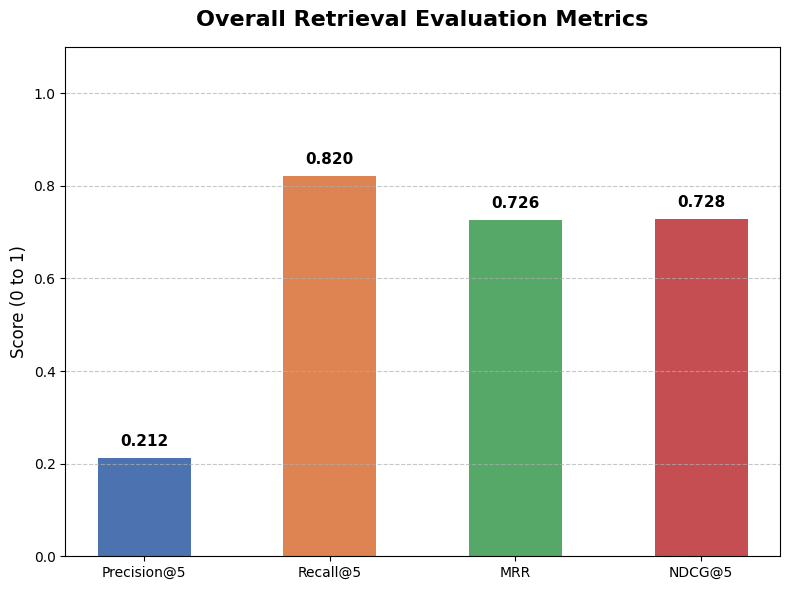

In [13]:
import matplotlib.pyplot as plt

# Extract values directly from your 'results' dictionary
labels = ['Precision@5', 'Recall@5', 'MRR', 'NDCG@5']
values = [
    eval_results.get('precision', 0),
    eval_results.get('recall', 0),
    eval_results.get('mrr', 0),
    eval_results.get('ndcg', 0)
]
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors, width=0.5)

# Formatting
plt.ylim(0, 1.1)
plt.title('Overall Retrieval Evaluation Metrics', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
             f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Generation

In [42]:
import os
from openai import OpenAI
load_dotenv(override=True) # Force reload .env to ensure we have the latest variables

# ==========================================
# 1. SETUP OPENROUTER CLIENT
# ==========================================
OPENROUTER_API_1 = os.getenv("OPENROUTER_API_1")  # Make sure this is set in your .env file
OPENROUTER_API_2 = load_dotenv("OPENROUTER_API_2")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_1,
)
LLM_MODEL1 = "openai/gpt-oss-120b:free"

# Using a free/fast model for evaluation
JUDGE_MODEL = "meta-llama/llama-3-8b-instruct:free"


In [48]:
def generate_legal_answer_GPT_OSS(query):
    print("🔍 1. Retrieving context from Qdrant...")
    # Call your exact search function
    retrieved_articles = juridical_search(query, limit=5)
    
    if not retrieved_articles:
        return "Je n'ai trouvé aucun article de loi correspondant à votre question."

    print("📝 2. Formatting context...")
    # Build a giant string containing all the retrieved texts
    context_text = ""
    for idx,article in enumerate(retrieved_articles, 1):
        art_id = article.get('id', 'Unknown ID')
        source = article.get('source', 'Unknown Source')
        text = article.get('text', '')
        
        context_text += f"\n--- Article {art_id} ---\n"
        context_text += f"Source: {source}\n"
        context_text += f"Texte: {text}\n"

    print (f"📚 Context {context_text}")
    
    print("🤖 3. Generating answer via OpenRouter...")
    
    # System prompt: Tells the AI HOW to behave
    system_prompt = """Tu es un assistant juridique expert en droit tunisien.
    Utilise UNIQUEMENT le contexte fourni pour répondre à la question de l'utilisateur.
    Si la réponse ne se trouve pas dans le contexte, dis simplement que tu ne sais pas.
    Cite toujours les numéros d'articles et la source dans ta réponse."""

    # User prompt: Combines the question and the retrieved context
    user_prompt = f"""
    CONTEXTE JURIDIQUE:
    {context_text}
    
    QUESTION DE L'UTILISATEUR:
    {query}
    """

    # Call the LLM
    response = client.chat.completions.create(
        model=LLM_MODEL1,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.1, # Low temperature so it doesn't hallucinate laws
    )

    return response.choices[0].message.content, context_text

In [49]:
user_question = "Qui est considéré juridiquement capable de contracter ?"

final_answer = generate_legal_answer_GPT_OSS(user_question)

print("\n" + "="*50)
print("⚖️ RÉPONSE GÉNÉRÉE :")
print("="*50)
print(final_answer)

🔍 1. Retrieving context from Qdrant...
📡 Qdrant found 5 candidates.
Original Top ID: 5
🏆 Reranked Top ID: 5 (Score: 0.9988)
📝 2. Formatting context...
📚 Context 
--- Article 5 ---
Source: Code Obligations Contrats
Texte: Sont absolument incapables de contracter, si ce n'est par les personnes qui les représentent : 1) les mineurs jusqu'à l'âge de treize ans révolus ; 2) les majeurs atteints d'aliénation mentale qui les prive complément de leurs facultés ; 3) les personnes morales que la loi assimile aux mineurs .

--- Article 3 ---
Source: Code Obligations Contrats
Texte: Toute personne est capable d'obliger et de s'obliger sauf si elle est déclarée incapable par la loi.

--- Article 14 ---
Source: Code Obligations Contrats
Texte: Le contractant capable de s'obliger ne peut opposer l' incapacité de la partie avec laquelle il a contracté.

--- Article 549 ---
Source: Code Obligations Contrats
Texte: Nul ne peut user des pouvoirs qu’il a pour autrui, par exemple comme administrateur ou tu

In [ ]:
import re
import time
import logging
from openai import OpenAI

# ==========================================
# 1. LOGGING CONFIGURATION
# ==========================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler("rag_evaluation.log", encoding='utf-8'),
        logging.StreamHandler()
    ],
    force=True 
)
logger = logging.getLogger(__name__)



In [ ]:

eval_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_2,
)

def extract_score(text):
    match = re.search(r"1\.0|0\.\d+|0|1", text)
    return float(match.group()) if match else 0.0

def ask_judge(prompt):
    try:
        response = eval_client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[
                {"role": "system", "content": "You are a strict legal auditor. Output ONLY a numerical score (0.0 to 1.0)."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0,
        )
        return extract_score(response.choices[0].message.content)
    except Exception as e:
        logger.error(f"Judge API Error: {e}")
        return 0.0

# ==========================================
# 3. METRIC DEFINITIONS
# ==========================================

def evaluate_faithfulness(context, answer):
    prompt = f"Does the answer only use context info?\nContext: {context}\nAnswer: {answer}\nScore 0 to 1:"
    return ask_judge(prompt)

def evaluate_relevancy(question, answer):
    prompt = f"Does this answer the question directly?\nQuestion: {question}\nAnswer: {answer}\nScore 0 to 1:"
    return ask_judge(prompt)


# ==========================================
# 4. MAIN EVALUATION LOOP
# ==========================================

def evaluate_generation_pipeline(dataset):
    logger.info(f"{'='*20} STARTING EVALUATION {'='*20}")
    
    # Store all scores in lists to calculate min/max/avg later
    f_scores, r_scores, c_scores = [], [], []
    num_queries = len(dataset)
    
    for idx, item in enumerate(dataset, 1):
        query = item['query']
        expected_desc = item['description']
        
        logger.info(f"TEST {idx}/{num_queries} | Query: {query}")
        
        try:
            # 1. Run RAG Pipeline
            final_answer, context_text = generate_legal_answer_GPT_OSS(query) 
            
            # 2. Get Scores
            f = evaluate_faithfulness(context_text, final_answer)
            r = evaluate_relevancy(query, final_answer)
            
            # Save scores
            f_scores.append(f)
            r_scores.append(r)
            
            # 3. Detailed Logging
            logger.info(f"ANSWER: {final_answer}")
            logger.info(f"SCORES: F={f} | R={r}")
            
        except Exception as e:
            logger.error(f"Failed test {idx}: {e}")
        
        # Rate limit protection
        if idx < num_queries:
            time.sleep(10)

    # 4. Calculate Final Statistics
    stats = {
        "faithfulness": {
            "avg": sum(f_scores) / len(f_scores) if f_scores else 0,
            "min": min(f_scores) if f_scores else 0,
            "max": max(f_scores) if f_scores else 0
        },
        "relevancy": {
            "avg": sum(r_scores) / len(r_scores) if r_scores else 0,
            "min": min(r_scores) if r_scores else 0,
            "max": max(r_scores) if r_scores else 0
        }
    }
    
    # 5. Log Summary
    logger.info(f"{'='*20} SESSION SUMMARY {'='*20}")
    for metric, val in stats.items():
        logger.info(f"{metric.upper()}: Avg={val['avg']:.2f}, Min={val['min']:.2f}, Max={val['max']:.2f}")
    logger.info(f"{'='*50}")

    return stats 

# Execute
final_stats = evaluate_generation_pipeline(mock_test_dataset)

In [ ]:
generation_results = evaluate_generation_pipeline(mock_test_dataset)